# **18장. 트랜스포머를 활용한 시계열 모델**

* 런타임 환경이 GPU로 설정되지 않으면 시간이 많이 걸릴수 있습니다.


In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 44.7 MB/s eta 0:00:00


[실습 18-01]

In [ ]:
!wget https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py  # 클래스가 정의된 파일 지정
from mini_transformers import TimeSeriesEmbedding, TransformerBlock

--2026-07-09 22:01:38--  https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7391 (7.2K) [text/plain]
Saving to: ‘mini_transformers.py’

mini_transformers.p 100%[===================>]   7.22K  --.-KB/s    in 0s      

2026-07-09 22:01:39 (91.7 MB/s) - ‘mini_transformers.py’ saved [7391/7391]



[실습 18-02]

In [ ]:
df=pd.read_csv("서울기온.csv", encoding="cp949").set_index("날짜")
df

,평균,최고,최저
날짜,,,
2006-01-01,1.4,1.8,0.6
2006-01-02,0.2,3.9,-2.4
2006-01-03,-2.4,1.2,-4.5
2006-01-04,-6.2,-4.4,-8.3
2006-01-05,-7.1,-2.5,-10.0
...,...,...,...
2025-12-27,-2.6,0.5,-8.3
2025-12-28,3.2,6.1,0.0
2025-12-29,4.9,9.1,-0.1


[실습 18-03]

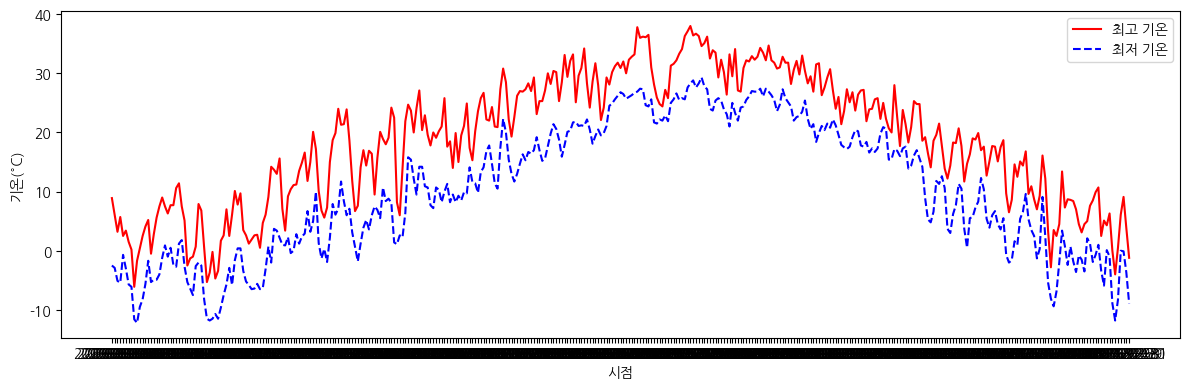

In [ ]:
plt.figure(figsize=(12, 4))

# 최근 1년 동안 기온
plt.plot(df[-365:]["최고"], "r-",  label='최고 기온')
plt.plot(df[-365:]["최저"], "b--", label='최저 기온')
plt.xlabel("시점")
plt.ylabel("기온(°C)")
plt.legend()
plt.tight_layout(); plt.show()


[실습 18-04]

In [ ]:
vars=df[["최고", "최저"]]  # 분석 대상 변수 설정
num_vars=vars.shape[1]     # 변수의 개수
var_names=vars.columns
print("변수의 개수=", num_vars); print()

# 스케일 정규화
scaler_mm=MinMaxScaler()
data = scaler_mm.fit_transform(vars)

# 입력과 타깃 변수 생성
seq_length = 90
print("입력 시퀀스의 길이= ", seq_length); print()
X, y = [], []
for i in range(len(data) - seq_length):
    X.append(data[i:i + seq_length,:])
    y.append(data[i + seq_length,:])
X=np.array(X); y=np.array(y)
print("전체 입력 데이터의 차원:", X.shape) # (샘플 수, 시퀀스 길이, 입력 변수의 수)
print("전체 타깃 데이터의 차원:", y.shape) # (샘플 수, 시퀀스 길이, 타깃 변수의 수)
print()

# 데이터 분할(시간 기준)
split=int(len(X)*0.8)
x_train=X[:split]; x_test=X[split:]
y_train=y[:split]; y_test=y[split:]
print("훈련용 입력 데이터 차원:", x_train.shape)
print("훈련용 타깃 데이터 차원:", y_train.shape)
print()
print("검증용 입력 데이터 차원:", x_test.shape)
print("검증용 타깃 데이터 차원:", y_test.shape)


변수의 개수= 2

입력 시퀀스의 길이=  90

전체 입력 데이터의 차원: (7215, 90, 2)
전체 타깃 데이터의 차원: (7215, 2)

훈련용 입력 데이터 차원: (5772, 90, 2)
훈련용 타깃 데이터 차원: (5772, 2)

검증용 입력 데이터 차원: (1443, 90, 2)
검증용 타깃 데이터 차원: (1443, 2)


[실습 18-05]

In [ ]:
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# 하이퍼 파라미터
embed_dim=64
num_heads=4
patch_size=1  # 패치의 크기
input_shape=x_train[0].shape

# 트랜스포머 모델 설정
model=Sequential([
      Input(shape=x_train[0].shape),

      TimeSeriesEmbedding(seq_length, patch_size, embed_dim),

      TransformerBlock(num_heads, use_causal_mask=True, return_sequences=True),
      TransformerBlock(num_heads, use_causal_mask=True, return_sequences=True),
      TransformerBlock(num_heads, use_causal_mask=True, return_sequences=True),
      TransformerBlock(num_heads, use_causal_mask=True, return_sequences=False),

      Dense(128, activation='relu'),
      Dropout(0.3),
      Dense(num_vars, activation='linear')
      ])

early_stop= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.compile(loss="mse", optimizer="adam", metrics=['mae'])
history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
    epochs=500, batch_size=32, callbacks=[early_stop])

Epoch 1/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - loss: 0.1364 - mae: 0.2246 - val_loss: 0.0073 - val_mae: 0.0702
Epoch 2/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0257 - mae: 0.1260 - val_loss: 0.0071 - val_mae: 0.0691
Epoch 3/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0191 - mae: 0.1084 - val_loss: 0.0054 - val_mae: 0.0605
Epoch 4/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0157 - mae: 0.0975 - val_loss: 0.0066 - val_mae: 0.0681
Epoch 5/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0144 - mae: 0.0937 - val_loss: 0.0036 - val_mae: 0.0473
Epoch 6/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0121 - mae: 0.0856 - val_loss: 0.0055 - val_mae: 0.0579
Epoch 7/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0108 - mae: 0.0807 - val_loss: 0.0080 - val_mae: 0.0762
Epoch 8/500
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0099 - mae: 0.0770 - val_loss: 0.0065 - val_mae: 0.0676
Epoch 9/500
181/181 ━━━━━━━━━━━━━━━━━━

예측 정확도 시각화

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step


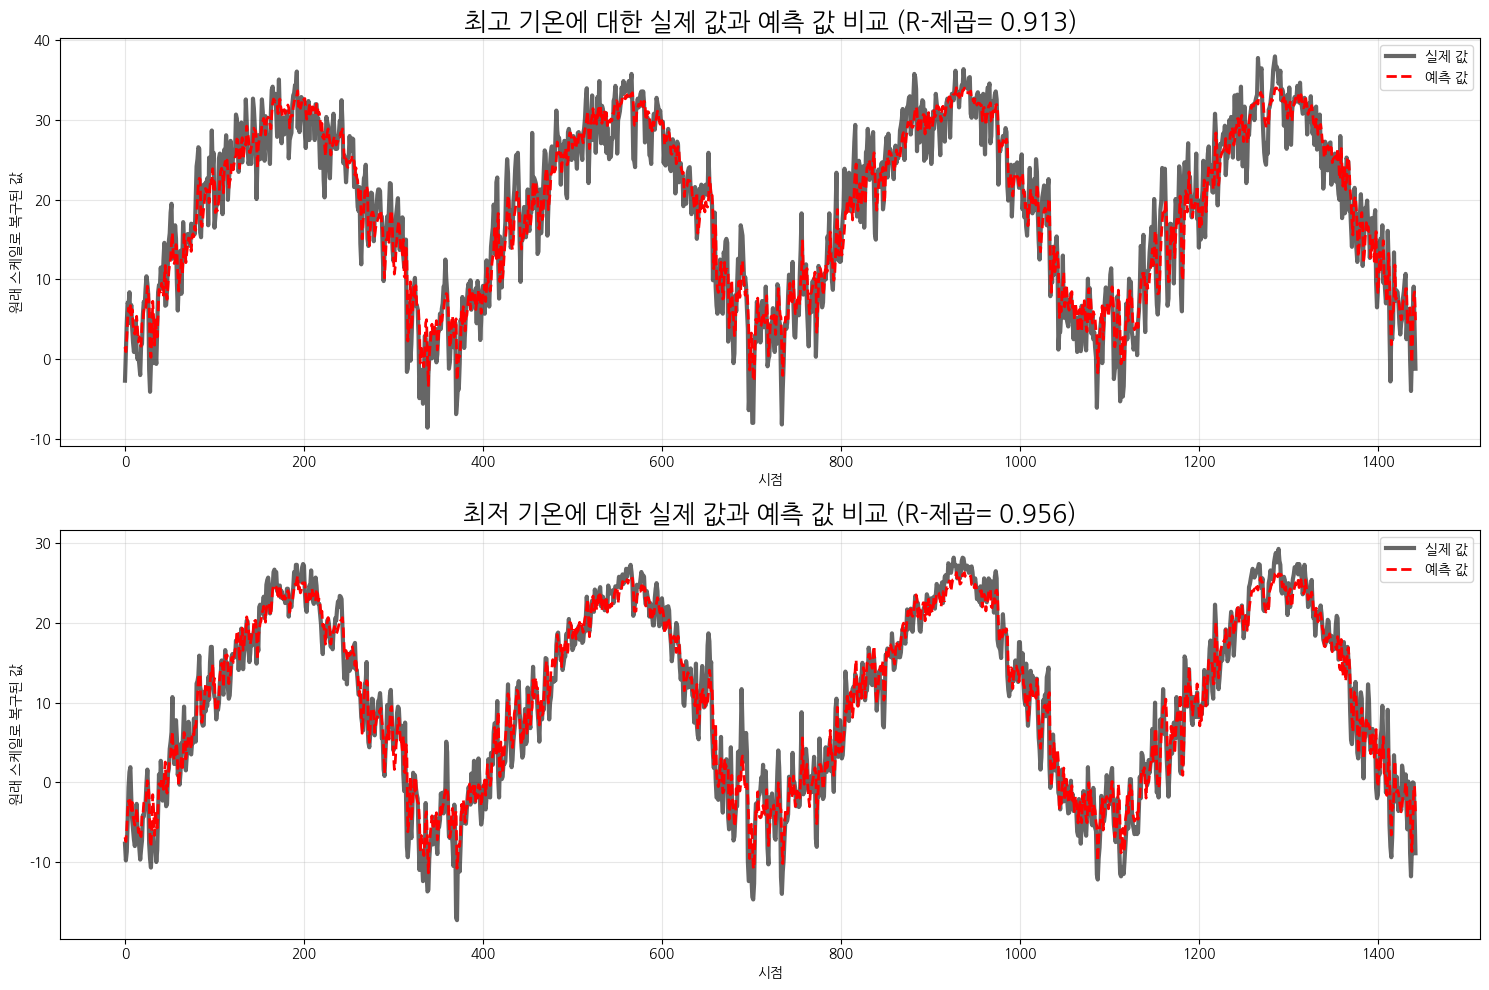

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 테스트 데이터에 대한 예측 수행
y_pred = model.predict(x_test)

# 스케일 복구
y_test_inverse = scaler_mm.inverse_transform(y_test)
y_pred_inverse = scaler_mm.inverse_transform(y_pred)

# R 제곱 계산
R=[]
for i in range(num_vars):
  R.append(r2_score(y_test[:, i], y_pred[:,i]))

# 시각화 (변수별 서브플롯 생성)
plt.figure(figsize=(15, 10))
for i in range(num_vars):
  #plt.figure(figsize=(15, 8))
  plt.subplot(num_vars, 1, i+1)
  plt.plot(y_test_inverse[:, i], label='실제 값', color='black', linewidth=3, alpha=0.6)
  plt.plot(y_pred_inverse[:, i], label='예측 값', color='red', linestyle='--', linewidth=2)
  plt.title(f"{var_names[i]} 기온에 대한 실제 값과 예측 값 비교 (R-제곱={R[i]: .3f})", fontsize=18)
  plt.xlabel("시점")
  plt.ylabel("원래 스케일로 복구된 값")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.tight_layout()
plt.show()

### 미래 예측

In [ ]:
def predict_future(model, seed_data, k_days):
    future_pred=[]
    data= seed_data.copy()
    for i in range(k_days):
        input_reshaped=data.reshape(1, seq_length, num_vars)  # 1. 모델 입력 모양 맞추기 (1, 60, 3)
        pred=model.predict(input_reshaped, verbose=0)         # 2. 다음 날 예측
        future_pred.append(pred[0])                           # 3. 예측결과 저장
        data=np.vstack([data[1:], pred])                      # 4. 시드 업데이트: 가장 오래된 데이터를 버리고 예측값을 맨 뒤에 추가
    future_pred=np.array(future_pred)                         # 5. 예측 값을 원래 스케일로 복구
    rescaled_pred=scaler_mm.inverse_transform(future_pred)
    return rescaled_pred

[실습 18-06]

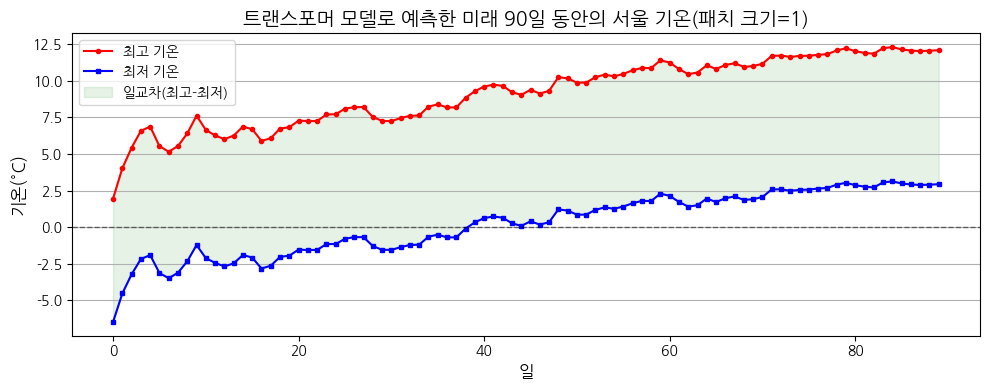

In [ ]:
K = 90                                                       # 미래 예측 기간 설정
seed = data[-seq_length:]                                    # 초기 입력으로 사용할 데이터 설정
forecast = predict_future(model, seed, K)

# 변수별 예측 값
future_max=forecast[:, 0]
future_min=forecast[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(future_max, label='최고 기온', color='red', marker='o', markersize=3)
plt.plot(future_min, label='최저 기온', color='blue', marker='s', markersize=3)
plt.fill_between(range(K), future_min, future_max,
                 color='green', alpha=0.1, label='일교차(최고-최저)')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.title(f"트랜스포머 모델로 예측한 미래 {K}일 동안의 서울 기온(패치 크기={patch_size})", fontsize=14)
plt.xlabel("일", fontsize=12)
plt.ylabel("기온(°C)", fontsize=12)
plt.grid(axis='y')
plt.legend(); plt.tight_layout(); plt.show()

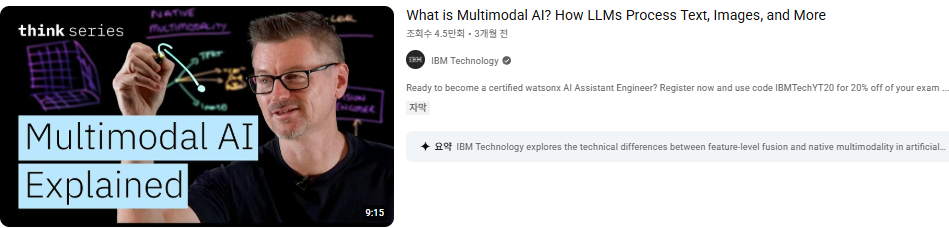

https://www.youtube.com/watch?v=J51oZYcNvP8

이 동영상은 트랜스포머를 사용하는 **멀티모달 AI** 모델의 구조를 설명합니다.

좀 어렵지만, 다양한 유형의 데이터가 하나의 고차원 임베딩 공간에서 고유한 벡터값을 가지는 **Shared Vector Space**에 주목해봅시다.

